# Projet Data Science : Pricing des billets d’avion

## Introduction
Le pricing des billets d’avion est un enjeu important pour les compagnies aériennes, 
car les prix varient selon de nombreux facteurs (date, demande, destination,etc). 
Le problème consiste à comprendre ces variations et à prédire le prix des billets. 
Ce projet cherche donc à identifier les facteurs influents et à construire un modèle capable d’estimer les prix.

### Objectifs du projet
-   Objectif principal
Construire un modèle de machine learning capable de prédire le prix d’un billet d’avion à partir des données disponibles.

-   Objectifs secondaires
    -   Identifier les facteurs qui influencent le plus le prix.
    -   Comprendre l’impact de la saisonnalité, des escales et du délai de réservation.
    -   Comparer plusieurs modèles de régression.
    -   Simuler un prix optimal en intégrant une logique de demande et de revenu.
    -   Fournir des recommandations business exploitables.

## 1-Préparation et prétraitement des données 

In [1]:
# importation des bibliothèques principales
import pandas as pd
import numpy as np
import re
import seaborn
import matplotlib.pyplot as plt

### Collecte et intégration des données
Pour ce projet, nous avons décidé de choisir un dataset issu de la platform Kaggle intitulé **Flight Price Dataset**.

Ce dataset regroupe plusieurs variables importantes telles que la **compagnie aérienne (Airline)**, **la date du voyage (Date_of_Journey)**, **es villes de départ et d’arrivée (Source et Destination)**, **les horaires de départ et d’arrivée (Dep_Time et Arrival_Time)**, **la durée du vol (Duration)**, **le nombre d’escales (Total_Stops)**, ainsi que **le prix du billet (Price)**, qui constitue la variable cible de notre étude

In [2]:
#Chargement des données en un seul dataset global qui contient tout le jeu de donées 
data_Train = pd.read_excel("Data_Train.xlsx")
data_Test = pd.read_excel("Test_set.xlsx")
data_prediction_test = pd.read_excel("Sample_submission.xlsx")
data_Test = pd.concat([data_Test, data_prediction_test], axis=1)
data = pd.concat([data_Train, data_Test], axis=0)

In [3]:
data.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [4]:
# informations relatives au dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13354 entries, 0 to 2670
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          13354 non-null  object
 1   Date_of_Journey  13354 non-null  object
 2   Source           13354 non-null  object
 3   Destination      13354 non-null  object
 4   Route            13353 non-null  object
 5   Dep_Time         13354 non-null  object
 6   Arrival_Time     13354 non-null  object
 7   Duration         13354 non-null  object
 8   Total_Stops      13353 non-null  object
 9   Additional_Info  13354 non-null  object
 10  Price            13354 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 1.2+ MB


In [5]:
# description des variables quantitatives contenues dans le dataset
data.describe()

,Price
count,13354.000000
mean,11301.720009
std,6452.843082
min,1759.000000
25%,6135.250000
50%,10262.000000
75%,14781.000000
max,79512.000000


In [6]:
#rechercheons les valeures nulles,
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
data[data.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [8]:
#drop the nullvalues
data.dropna(inplace=True)

In [9]:
data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [10]:
def change_into_datetime(col):
    data[col]=pd.to_datetime(data[col])

In [11]:
for i in ['Date_of_Journey','Dep_Time', 'Arrival_Time']:
    change_into_datetime(i)

C:\Users\landr\AppData\Local\Temp\ipykernel_33100\1802885727.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data[col]=pd.to_datetime(data[col])
C:\Users\landr\AppData\Local\Temp\ipykernel_33100\1802885727.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col]=pd.to_datetime(data[col])
C:\Users\landr\AppData\Local\Temp\ipykernel_33100\1802885727.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col]=pd.to_datetime(data[col])


In [12]:
data.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time           datetime64[ns]
Arrival_Time       datetime64[ns]
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

In [13]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-04-03 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-04-03 05:50:00,2026-04-03 13:15:00,7h 25m,2 stops,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-04-03 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-04-03 18:05:00,2026-04-03 23:30:00,5h 25m,1 stop,No info,6218
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-04-03 16:50:00,2026-04-03 21:35:00,4h 45m,1 stop,No info,13302


In [14]:
data["mois_depart"] = data["Date_of_Journey"].dt.month
data["jour_depart"] = data["Date_of_Journey"].dt.day

In [15]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-04-03 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-04-03 05:50:00,2026-04-03 13:15:00,7h 25m,2 stops,No info,7662,5,1
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-04-03 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,6,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-04-03 18:05:00,2026-04-03 23:30:00,5h 25m,1 stop,No info,6218,5,12
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-04-03 16:50:00,2026-04-03 21:35:00,4h 45m,1 stop,No info,13302,3,1


In [16]:
# Modifions le format des heures de départ et d'arriivée
data["Dep_Time"] = data["Dep_Time"].dt.strftime("%H:%M")
data["Arrival_Time"] = data["Arrival_Time"].dt.strftime("%H:%M")

In [17]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,mois_depart,jour_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,3,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,1
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,6,9
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,5,12
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,3,1


In [18]:
def convertion_duree(x):
    x = str(x)
    h = 0
    m = 0

    if "h" in x:
        h = int(x.split("h")[0])

    if "m" in x:
        if "h" in x:
            m = int(x.split("h")[1].replace("m", "").strip())
        else:
            m = int(x.replace("m", ""))

    return h*60 + m

data["duree_min"] = data["Duration"].apply(convertion_duree)
data.drop(columns= "Duration", inplace= True)

In [19]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10,non-stop,No info,3897,3,24,170
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,2 stops,No info,7662,5,1,445
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,2 stops,No info,13882,6,9,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,1 stop,No info,6218,5,12,325
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,1 stop,No info,13302,3,1,285


In [20]:
# Supprimons la variable route car nous avons la variable Total_Stops qui nous traduit déjà le nombre total d'escale
data.drop("Route", axis=1, inplace=True)

In [21]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,01:10,non-stop,No info,3897,3,24,170
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,2 stops,No info,7662,5,1,445
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,2 stops,No info,13882,6,9,1140
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,1 stop,No info,6218,5,12,325
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,1 stop,No info,13302,3,1,285


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13353 entries, 0 to 2670
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          13353 non-null  object        
 1   Date_of_Journey  13353 non-null  datetime64[ns]
 2   Source           13353 non-null  object        
 3   Destination      13353 non-null  object        
 4   Dep_Time         13353 non-null  object        
 5   Arrival_Time     13353 non-null  object        
 6   Total_Stops      13353 non-null  object        
 7   Additional_Info  13353 non-null  object        
 8   Price            13353 non-null  int64         
 9   mois_depart      13353 non-null  int32         
 10  jour_depart      13353 non-null  int32         
 11  duree_min        13353 non-null  int64         
dtypes: datetime64[ns](1), int32(2), int64(2), object(7)
memory usage: 1.2+ MB


In [23]:
data["dep_hour"] = data["Dep_Time"].str.split(":").str[0].astype(int)
data["arr_hour"] = data["Arrival_Time"].str.split(":").str[0].astype(int)

In [24]:
def periode_jour(h):
    if h < 6:
        return "nuit"
    elif h < 12:
        return "matin"
    elif h < 18:
        return "apres_midi"
    else:
        return "soir"

data["periode_depart"] = data["dep_hour"].apply(periode_jour)

In [25]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,Banglore,New Delhi,22:20,01:10,non-stop,No info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,Kolkata,Banglore,05:50,13:15,2 stops,No info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,Delhi,Cochin,09:25,04:25,2 stops,No info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,Kolkata,Banglore,18:05,23:30,1 stop,No info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,Banglore,New Delhi,16:50,21:35,1 stop,No info,13302,3,1,285,16,21,apres_midi


In [26]:
data["Additional_Info"].value_counts()

Additional_Info
No info                         10492
In-flight meal not included      2426
No check-in baggage included      396
1 Long layover                     20
Change airports                     8
Business class                      5
No Info                             3
1 Short layover                     1
Red-eye flight                      1
2 Long layover                      1
Name: count, dtype: int64

In [27]:
# passons à la colone Additional_Info et mettons tous ces caracteres en miniscule
data["Additional_Info"] = (
    data["Additional_Info"]
    .str.lower()
    .str.strip()
)

In [28]:
data["Additional_Info"].value_counts()

Additional_Info
no info                         10495
in-flight meal not included      2426
no check-in baggage included      396
1 long layover                     20
change airports                     8
business class                      5
1 short layover                     1
red-eye flight                      1
2 long layover                      1
Name: count, dtype: int64

In [29]:
# passons à la colone Source et mettons tous ces caracteres en miniscule
data["Source"] = (
    data_Train["Source"]
    .str.lower()
    .str.strip()
)
data["Source"].value_counts()

Source
delhi       5691
kolkata     3552
banglore    2772
mumbai       858
chennai      480
Name: count, dtype: int64

In [30]:
# passons à la colone Destination et mettons tous ces caracteres en miniscule
data["Destination"] = (
    data["Destination"]
    .str.lower()
    .str.strip()
)
data["Destination"].value_counts()

Destination
cochin       5681
banglore     3581
delhi        1582
new delhi    1170
hyderabad     883
kolkata       456
Name: count, dtype: int64

In [31]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,banglore,new delhi,22:20,01:10,non-stop,no info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,kolkata,banglore,05:50,13:15,2 stops,no info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,delhi,cochin,09:25,04:25,2 stops,no info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,kolkata,banglore,18:05,23:30,1 stop,no info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,banglore,new delhi,16:50,21:35,1 stop,no info,13302,3,1,285,16,21,apres_midi


Passons à la colone Total_Stops nous allons convertir la variablecatégorielle "Total_Stops" en variable numérique afin de la rendre exploitable par les modèles de machine learning.

In [32]:
data["Total_Stops"].value_counts()

Total_Stops
1 stop      7056
non-stop    4340
2 stops     1899
3 stops       56
4 stops        2
Name: count, dtype: int64

In [33]:
data["Total_Stops"] = data["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

C:\Users\landr\AppData\Local\Temp\ipykernel_33100\1188834133.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Total_Stops"] = data["Total_Stops"].replace({


In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13353 entries, 0 to 2670
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          13353 non-null  object        
 1   Date_of_Journey  13353 non-null  datetime64[ns]
 2   Source           13353 non-null  object        
 3   Destination      13353 non-null  object        
 4   Dep_Time         13353 non-null  object        
 5   Arrival_Time     13353 non-null  object        
 6   Total_Stops      13353 non-null  int64         
 7   Additional_Info  13353 non-null  object        
 8   Price            13353 non-null  int64         
 9   mois_depart      13353 non-null  int32         
 10  jour_depart      13353 non-null  int32         
 11  duree_min        13353 non-null  int64         
 12  dep_hour         13353 non-null  int64         
 13  arr_hour         13353 non-null  int64         
 14  periode_depart   13353 non-null  object     

In [35]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Total_Stops,Additional_Info,Price,mois_depart,jour_depart,duree_min,dep_hour,arr_hour,periode_depart
0,IndiGo,2019-03-24,banglore,new delhi,22:20,01:10,0,no info,3897,3,24,170,22,1,soir
1,Air India,2019-05-01,kolkata,banglore,05:50,13:15,2,no info,7662,5,1,445,5,13,nuit
2,Jet Airways,2019-06-09,delhi,cochin,09:25,04:25,2,no info,13882,6,9,1140,9,4,matin
3,IndiGo,2019-05-12,kolkata,banglore,18:05,23:30,1,no info,6218,5,12,325,18,23,soir
4,IndiGo,2019-03-01,banglore,new delhi,16:50,21:35,1,no info,13302,3,1,285,16,21,apres_midi


In [36]:
data["Total_Stops"] = data["Total_Stops"].astype(int)

In [37]:
# Redéfinissons les colones afin d'avoir un data plus clean
colonnes = [
    "Airline",
    "Source",
    "Destination",
    "Date_of_Journey",
    "mois_depart",
    "jour_depart",
    "Dep_Time",
    "dep_hour",
    "periode_depart",
    "Arrival_Time",
    "arr_hour",
    "duree_min",
    "Total_Stops",
    "Additional_Info",
    "Price"
]

data = data[colonnes]

data.head()

,Airline,Source,Destination,Date_of_Journey,mois_depart,jour_depart,Dep_Time,dep_hour,periode_depart,Arrival_Time,arr_hour,duree_min,Total_Stops,Additional_Info,Price
0,IndiGo,banglore,new delhi,2019-03-24,3,24,22:20,22,soir,01:10,1,170,0,no info,3897
1,Air India,kolkata,banglore,2019-05-01,5,1,05:50,5,nuit,13:15,13,445,2,no info,7662
2,Jet Airways,delhi,cochin,2019-06-09,6,9,09:25,9,matin,04:25,4,1140,2,no info,13882
3,IndiGo,kolkata,banglore,2019-05-12,5,12,18:05,18,soir,23:30,23,325,1,no info,6218
4,IndiGo,banglore,new delhi,2019-03-01,3,1,16:50,16,apres_midi,21:35,21,285,1,no info,13302


### 2- Visualisation des données:
cette approche est utilisé pour:
-comprendre les rélations entre les données et déterminer les données importantes 
-mener des analyse données
-comprendre la répartition des données 

In [38]:
#importation des bibiothèques utiles
import seaborn as sns 
import matplotlib.pyplot as plt

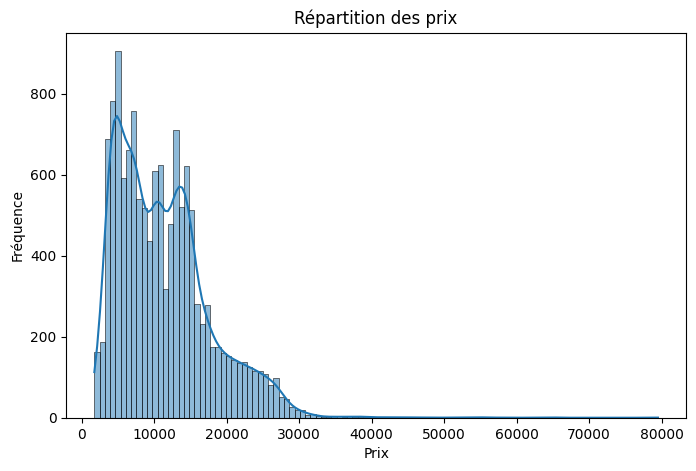

In [39]:
#Visualisation de la répartition des données: ce visuel permet de voir la répartition des données( symetrique/asymétrique) 
#---ce visuel permet également de déterminé les valeurs abérante qui pourrais influencer les corrélations

plt.figure(figsize=(8,5))
sns.histplot(data['Price'], kde=True)  # kde = courbe de densité
plt.title('Répartition des prix')
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.show()

Interprétation: ce visuel permet de voir que les données sont asymétrique, ceci nous permet de comprends qu'il serait important d'utiliser les valeurs médianes aux valeurs moyenne dans nos calculs car les valeurs médiane ne sont pas affectés par la répartition asymétrique comme les valeurs moyenne
deplus on constate qu'il y'a pas de valeurs abérantes

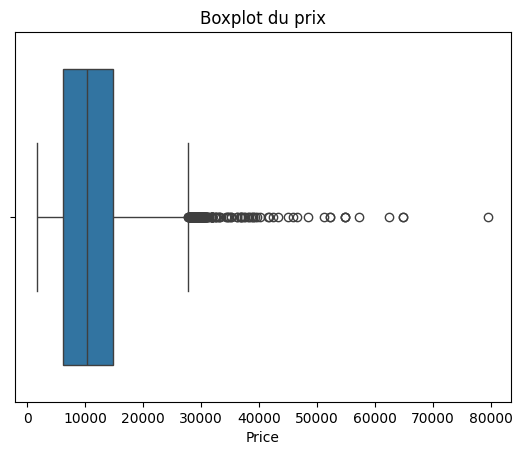

In [40]:
sns.boxplot(x=data["Price"])
plt.title("Boxplot du prix")
plt.show()

L’analyse du boxplot montre une distribution asymétrique des prix avec une forte présence de valeurs extrêmes. La majorité des observations se concentre entre 5 000 et 15 000, tandis que certains billets présentent des prix très élevés. Ces valeurs peuvent correspondre à des situations spécifiques comme des vols longue distance ou premium.

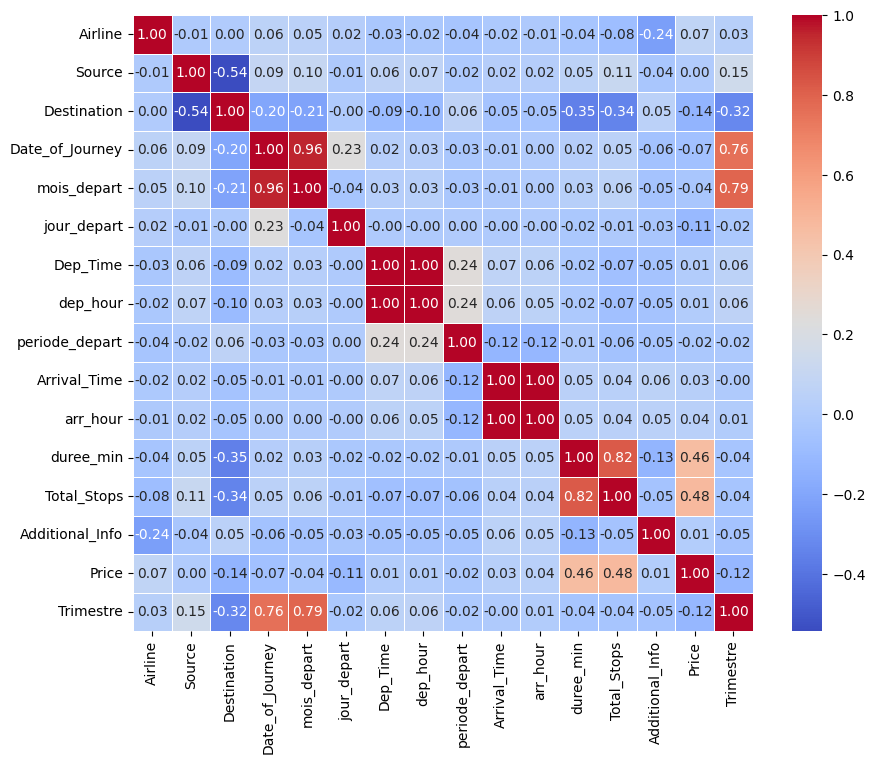

In [41]:
#Matrice de correlation: nécéssaire pour trouver les rélations entre les variables

#--création de la colone Trimestre pour vérifier si le prix du billet d'avion dépend de la période
data['Trimestre'] = ((data['mois_depart'] - 1) // 3) + 1

#encodage des variables catégorielle pour etre sur d'avoir toute les corrélation dans le dataset
from sklearn.preprocessing import LabelEncoder
plt.figure(figsize=(10, 8))
df_encoded = data.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

#matrice de correlation en représentation graphique pour avoir une meilleur vue sur les coefficients et les corrélation dans le dataset
corr = df_encoded.corr(method='spearman')

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

interprétation: de cette matrice de correlation on voit qu'il n'ya que la durée du vol et le nombre de stop qui sont en corrélation linéaire forte avec le prix des billets,tant dis que les autres sont en faible corrélation linéair,
N.B: ceci ne veut pas dire qu'il y'a pas de rélation entre le prix et les autres valeurs, juste que cette rélation n'est pas linéaire

Nous allons maintenant nous pencher sur une analyse visuelle des différents parametres pouvant influencer le prix des billets d'avion 

In [42]:
#vérifier le nombre de vols par trimestre
data_group=data.groupby("Trimestre")["Trimestre"].count()
data_group

Trimestre
1    3412
2    9941
Name: Trimestre, dtype: int64

In [43]:
data_Test.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,Jet Airways,6/06/2019,Delhi,Cochin,DEL → BOM → COK,17:30,04:25 07 Jun,10h 55m,1 stop,No info,15998
1,IndiGo,12/05/2019,Kolkata,Banglore,CCU → MAA → BLR,06:20,10:20,4h,1 stop,No info,16612
2,Jet Airways,21/05/2019,Delhi,Cochin,DEL → BOM → COK,19:15,19:00 22 May,23h 45m,1 stop,In-flight meal not included,25572
3,Multiple carriers,21/05/2019,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,13h,1 stop,No info,25778
4,Air Asia,24/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 25 Jun,2h 50m,non-stop,No info,16934


In [44]:
print(data.columns)

Index(['Airline', 'Source', 'Destination', 'Date_of_Journey', 'mois_depart',
       'jour_depart', 'Dep_Time', 'dep_hour', 'periode_depart', 'Arrival_Time',
       'arr_hour', 'duree_min', 'Total_Stops', 'Additional_Info', 'Price',
       'Trimestre'],
      dtype='object')


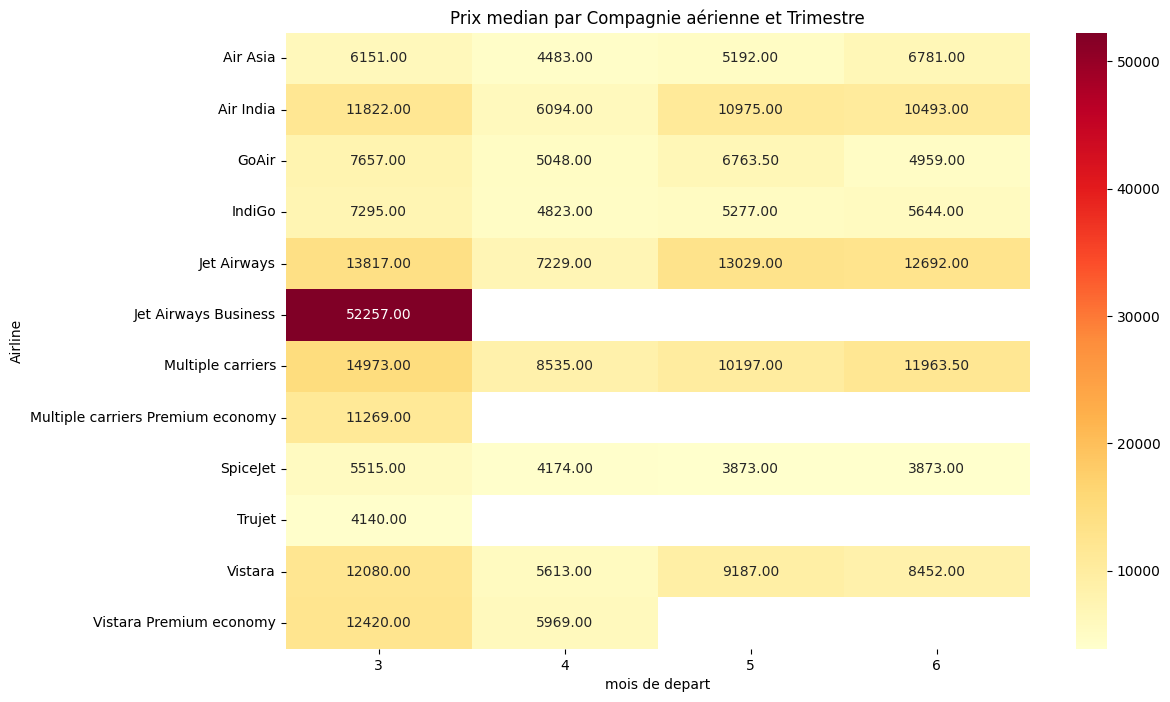

In [45]:
#visuel des prix en fonctions des campagnies et des trimestres

import seaborn as sns
import matplotlib.pyplot as plt


data_1= data.groupby("Trimestre")["Price"].mean()
pivot_table = data.pivot_table(values='Price', index='Airline', columns='mois_depart', aggfunc='median')

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title('Prix median par Compagnie aérienne et Trimestre')
plt.ylabel('Airline')
plt.xlabel('mois de depart')
plt.show()

on voit ici que les prix sont influencés par la compagnie aériennes et par la période de l'année de l'année

C:\Users\landr\AppData\Local\Temp\ipykernel_33100\217399716.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(y=data2["mois_depart"], x=data2["count"],orient='h',palette='viridis')


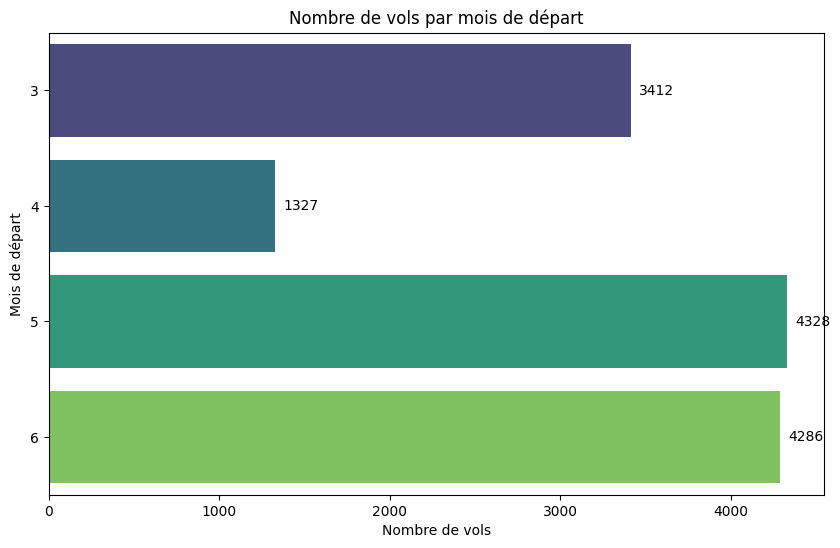

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
data2 = data.groupby("mois_depart")["mois_depart"].count().reset_index(name='count')
plt.figure(figsize=(10,6))
barplot = sns.barplot(y=data2["mois_depart"], x=data2["count"],orient='h',palette='viridis')

plt.xlabel('Nombre de vols')
plt.ylabel('Mois de départ')
plt.title('Nombre de vols par mois de départ')

# Ajouter les valeurs au bout des barres
for index, value in enumerate(data2["count"]):
    barplot.text(value + 50, index, str(value), va='center')

plt.show()

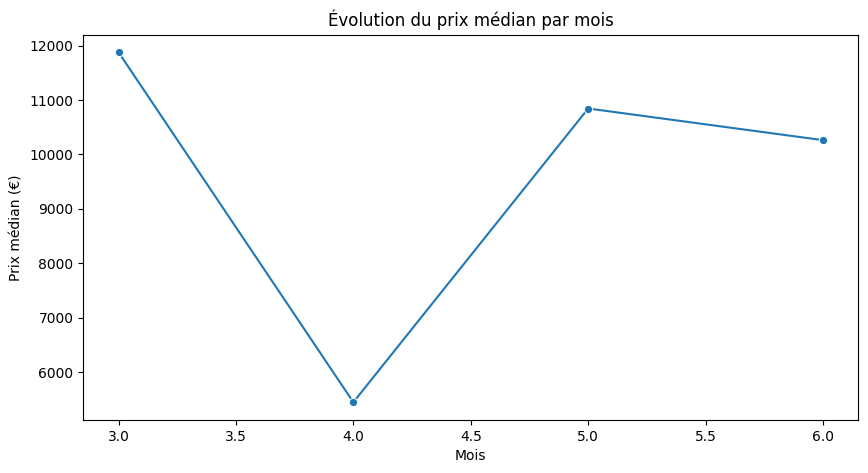

In [47]:
median_price_month = data.groupby('mois_depart')['Price'].median().reset_index()
plt.figure(figsize=(10,5))

sns.lineplot(data=median_price_month, x='mois_depart', y='Price', marker='o')

plt.title('Évolution du prix médian par mois')
plt.xlabel('Mois')
plt.ylabel('Prix médian (€)')
plt.show()

C:\Users\landr\AppData\Local\Temp\ipykernel_33100\3136769588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=median_price_by_stops, x='Total_Stops', y='Price', palette='coolwarm')


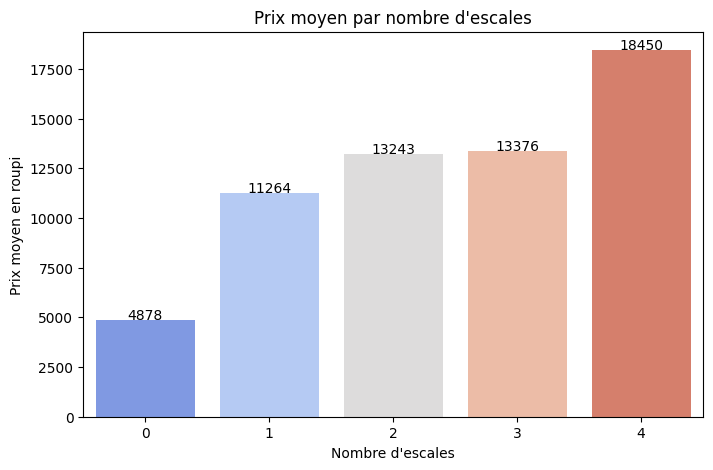

In [48]:
#visualisation du prix par nombre d'escale
plt.figure(figsize=(8,5))
median_price_by_stops = data.groupby('Total_Stops')['Price'].median().reset_index()
ax = sns.barplot(data=median_price_by_stops, x='Total_Stops', y='Price', palette='coolwarm')

# Ajout des valeurs sur le graphes
for i, value in enumerate(median_price_by_stops['Price']):
    ax.text(i, value + 10, f'{value:.0f}', ha='center')

plt.xlabel('Nombre d\'escales')
plt.ylabel('Prix moyen en roupi')
plt.title('Prix moyen par nombre d\'escales')
plt.show()

comme obtenu dans la matrice de correlation, le prix est bien lié au prix et plus il y'a d'escale, plus le prix est élévé

C:\Users\landr\AppData\Local\Temp\ipykernel_33100\2733699344.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=median_price, x='periode_depart', y='Price', palette='viridis')


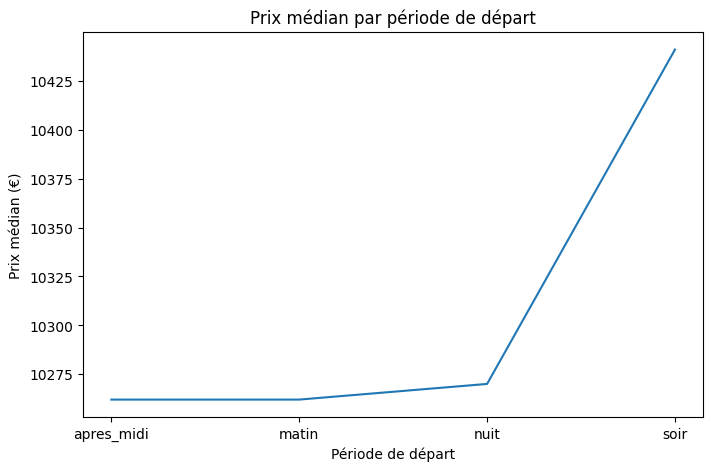

In [49]:
#prix par période de départ
median_price = data.groupby('periode_depart')['Price'].median().reset_index()
median_price
plt.figure(figsize=(8,5))
sns.lineplot(data=median_price, x='periode_depart', y='Price', palette='viridis')

plt.xlabel('Période de départ')
plt.ylabel('Prix médian (€)')
plt.title('Prix médian par période de départ')
plt.show()

ce graphe nous permet de comprendre également que le prix est influencé par la péridoe de départ

 ### Analyse multivariée

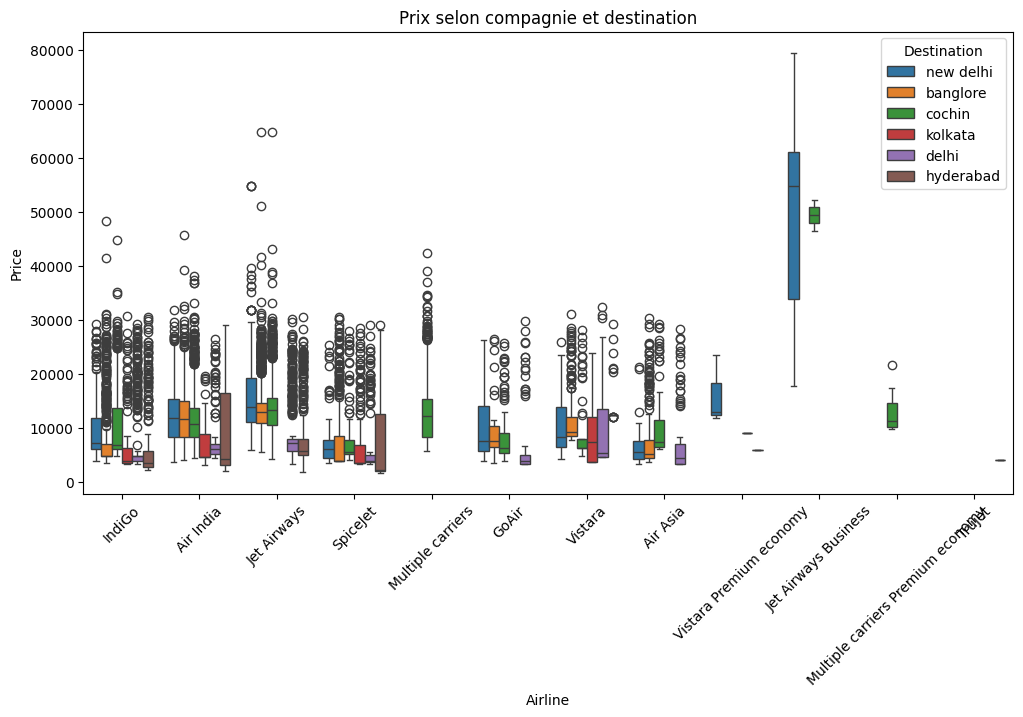

In [50]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Airline", y="Price", hue=(data["Destination"]) , data=data)
plt.xticks(rotation=45)
plt.title("Prix selon compagnie et destination")
plt.show()

Certaines compagnies proposent des prix moyens relativement bas pour la globalité des destinations c'est le cas des compagnies **IndiGo, SpiceJet, Air Asia**

Or d'autres proposent des prix moyens très élévé pour les mêmes destinations

In [51]:
data.head()

,Airline,Source,Destination,Date_of_Journey,mois_depart,jour_depart,Dep_Time,dep_hour,periode_depart,Arrival_Time,arr_hour,duree_min,Total_Stops,Additional_Info,Price,Trimestre
0,IndiGo,banglore,new delhi,2019-03-24,3,24,22:20,22,soir,01:10,1,170,0,no info,3897,1
1,Air India,kolkata,banglore,2019-05-01,5,1,05:50,5,nuit,13:15,13,445,2,no info,7662,2
2,Jet Airways,delhi,cochin,2019-06-09,6,9,09:25,9,matin,04:25,4,1140,2,no info,13882,2
3,IndiGo,kolkata,banglore,2019-05-12,5,12,18:05,18,soir,23:30,23,325,1,no info,6218,2
4,IndiGo,banglore,new delhi,2019-03-01,3,1,16:50,16,apres_midi,21:35,21,285,1,no info,13302,1


## Modelisation

Passons à la preparation  de notre dataset pour la modélisation

In [52]:
data_model = data[[
    "Airline", 
    "Source", 
    "Destination", 
    "mois_depart", 
    "jour_depart", 
    "dep_hour", 
    "arr_hour",
    "duree_min", 
    "Total_Stops",  
    "Additional_Info", 
    "Price"
]].copy()

In [53]:
data_model.head()

,Airline,Source,Destination,mois_depart,jour_depart,dep_hour,arr_hour,duree_min,Total_Stops,Additional_Info,Price
0,IndiGo,banglore,new delhi,3,24,22,1,170,0,no info,3897
1,Air India,kolkata,banglore,5,1,5,13,445,2,no info,7662
2,Jet Airways,delhi,cochin,6,9,9,4,1140,2,no info,13882
3,IndiGo,kolkata,banglore,5,12,18,23,325,1,no info,6218
4,IndiGo,banglore,new delhi,3,1,16,21,285,1,no info,13302


### Encodage des variables catégorielles

In [54]:
# Pour l'encodage des variables catégorielles, nous allons opter pour l'option OneHot encoding car Il transforme les données catégorielles en un format que les modèles d'apprentissage automatique peuvent facilement comprendre et utiliser. Cette transformation permet de traiter chaque catégorie de manière indépendante sans impliquer de fausses relations entre elles.
data_model = pd.get_dummies(
    data_model,
    columns=["Airline", "Source", "Destination", "Additional_Info"],
    drop_first=True
)
# Séparation des features et target
X = data_model.drop("Price", axis=1)
y = data_model["Price"]

In [55]:
data_model.head()

,mois_depart,jour_depart,dep_hour,arr_hour,duree_min,Total_Stops,Price,Airline_Air India,Airline_GoAir,Airline_IndiGo,...,Destination_kolkata,Destination_new delhi,Additional_Info_1 short layover,Additional_Info_2 long layover,Additional_Info_business class,Additional_Info_change airports,Additional_Info_in-flight meal not included,Additional_Info_no check-in baggage included,Additional_Info_no info,Additional_Info_red-eye flight
0,3,24,22,1,170,0,3897,False,False,True,...,False,True,False,False,False,False,False,False,True,False
1,5,1,5,13,445,2,7662,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,6,9,9,4,1140,2,13882,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,5,12,18,23,325,1,6218,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,3,1,16,21,285,1,13302,False,False,True,...,False,True,False,False,False,False,False,False,True,False


## Model 1 : Random forest

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

mae_scores = -scores

print("MAE par fold :", mae_scores)
print("MAE moyen :", mae_scores.mean())
print("Ecart-type :", mae_scores.std())

MAE par fold : [2481.75022647 2515.88760893 2376.57888944 2490.11191065 2625.88938153]
MAE moyen : 2498.043603403764
Ecart-type : 79.68063019177953


Model 2: Arbre de Décision

In [59]:
#importation des bibiothèques utiles
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#  Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Définition du modèle d'arbre
model = DecisionTreeRegressor(random_state=42)

#  Définition de la grille d'hyperparamètres
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [5, 10, 20, 30],
    'min_samples_leaf': [2, 5, 10, 20]
}
# implémentation du gridsearch pour rechercher les paramètres qui rendent le modèle le plus performent possible
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,  
    scoring='neg_mean_squared_error',  
    n_jobs=-1
)
# Entraînement
grid_search.fit(X_train, y_train)

# récupération des Meilleurs paramètres
print("Meilleurs paramètres :", grid_search.best_params_)

#  Prédiction sur test
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Évaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.2f}")

Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 30}
MAE : 2557.75
RMSE : 4351.76
R² : 0.56


Modèle 3 : SVM (SVR)

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

#  Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardiser les features pour SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Définition du modèle SVR
svr = SVR()

#  Grille d'hyperparamètres
param_grid = {
    'kernel': ['sigmoid'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']  # uniquement pour 'rbf', 'poly', 'sigmoid'
}

#  GridSearchCV
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',  # optimisé pour RMSE
)

# Entraînement
grid_search.fit(X_train_scaled, y_train)

#  Meilleurs paramètres
print("Meilleurs paramètres :", grid_search.best_params_)

#  Prédiction
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# Évaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.2f}")


Meilleurs paramètres : {'C': 10, 'gamma': 'auto', 'kernel': 'sigmoid'}
MAE : 3973.07
RMSE : 6307.07
R² : 0.07


In [ ]:
# Imports
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# séparation Split\test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# standadisation des variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Kernels à tester
kernels = ['linear', 'rbf', 'poly']

# recherche du meilleur modele 
results = {}

#  Boucle sur les kernels
for kernel in kernels:
    # Grille adaptée selon le kernel
    if kernel == 'linear':
        param_grid = {
            'C': [0.1, 1, 10]
        }
    else:
        param_grid = {
            'C': [0.1, 1, 10],
            'epsilon': [0.1, 0.5],
            'gamma': ['scale', 'auto']
        }
    
    # Modèle
    svr = SVR(kernel=kernel)
    # GridSearch
    grid = GridSearchCV(
        svr,
        param_grid,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    grid.fit(X_train_scaled, y_train)
    
    # Meilleur modèle
    best_model = grid.best_estimator_
    
    # Prédictions
    y_pred = best_model.predict(X_test_scaled)
    
    # Métriques
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Stockage
    results[kernel] = {
        "best_params": grid.best_params_,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
# Trouver le meilleur noyau (RMSE le plus faible)
best_kernel = min(results, key=lambda k: results[k]["RMSE"])
y_pred = best_model.predict(X_test_scaled)

print(f" Meilleur modèle : {best_kernel}")
#  Évaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.2f}")


 Meilleur modèle : linear
MAE : 4479.31
RMSE : 6072.61
R² : 0.14
